### Plotting the result

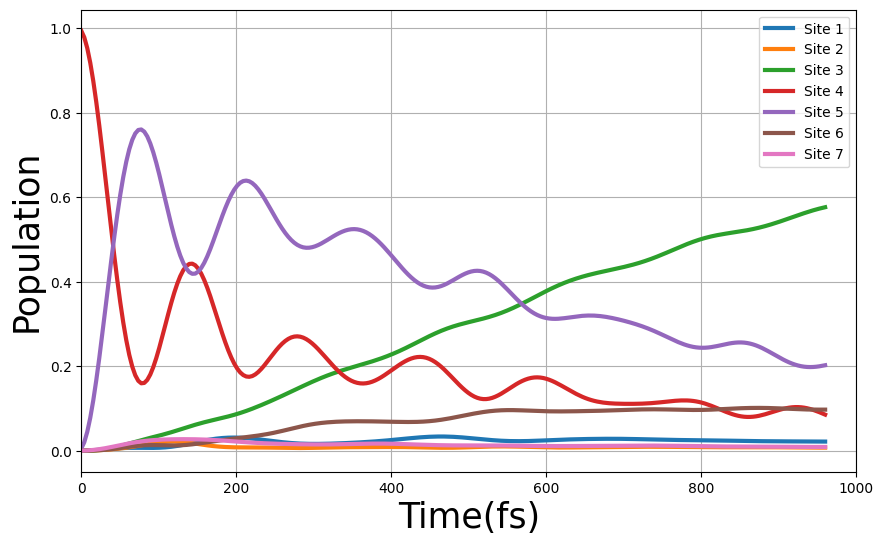

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取Excel文件
df = pd.read_excel('2026-03-18-1601_FMO16bd_160t.xlsx')
# df = pd.read_excel('../../fmo_benchmark.xlsx')

# 提取数据
x = np.arange(0,df.shape[0],1)
x = x * 160 * 0.024188843265

y_columns = df.iloc[:, 0:7]  # 第1-7列作为y坐标

# 创建图表
plt.figure(figsize=(10, 6))

# 绘制七条线
for i in range(0,7):
    plt.plot(x, y_columns.iloc[:, i],label=f'Site {i+1}',linewidth=3)

# 添加图表元素
plt.xlabel('Time(fs)',size = 25)
plt.ylabel('Population',size = 25)
plt.xlim((0, 1000))
plt.title('')
plt.legend()
plt.grid(True)

# 显示图表
plt.show()

### Plotting the error

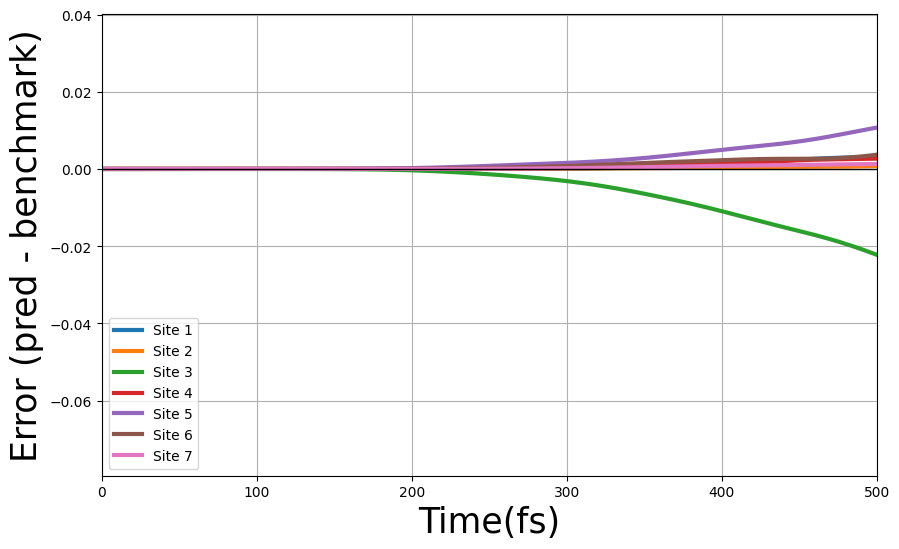

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 读取 benchmark（行数更多）
df_bm = pd.read_excel('fmo_benchmark_128bd.xlsx')

# 时间步长（与你第一张图一致）
dt = 160 * 0.024188843265

# pred(你的结果) 的时间轴：用第一张图里的 df（确保第一个 block 已运行）
x_pred = np.arange(df.shape[0]) * dt
y_pred = df.iloc[:, 0:7].to_numpy()

# benchmark 的时间轴
x_bm = np.arange(df_bm.shape[0]) * dt
y_bm = df_bm.iloc[:, 0:7].to_numpy()

# 将 benchmark 插值到 pred 的时间点上，然后算误差：pred - benchmark
y_bm_on_pred = np.column_stack([
    np.interp(x_pred, x_bm, y_bm[:, i]) for i in range(7)
])
err = y_pred - y_bm_on_pred
# 如果你想画绝对误差：err = np.abs(err)

# 画误差图
plt.figure(figsize=(10, 6))
for i in range(7):
    plt.plot(x_pred, err[:, i], label=f'Site {i+1}', linewidth=3)

plt.axhline(0, color='k', linewidth=1)
plt.xlabel('Time(fs)', size=25)
plt.ylabel('Error (pred - benchmark)', size=25)
plt.xlim((0, 500))
plt.title('')
plt.legend()
plt.grid(True)
plt.show()

Found 3 data files to plot.
Benchmark file: fmo_benchmark_128bd.xlsx
  - Plotted: FMO16bd_160t
  - Plotted: FMO16bd_160t
  - Plotted: fmo_benchmark_32bd


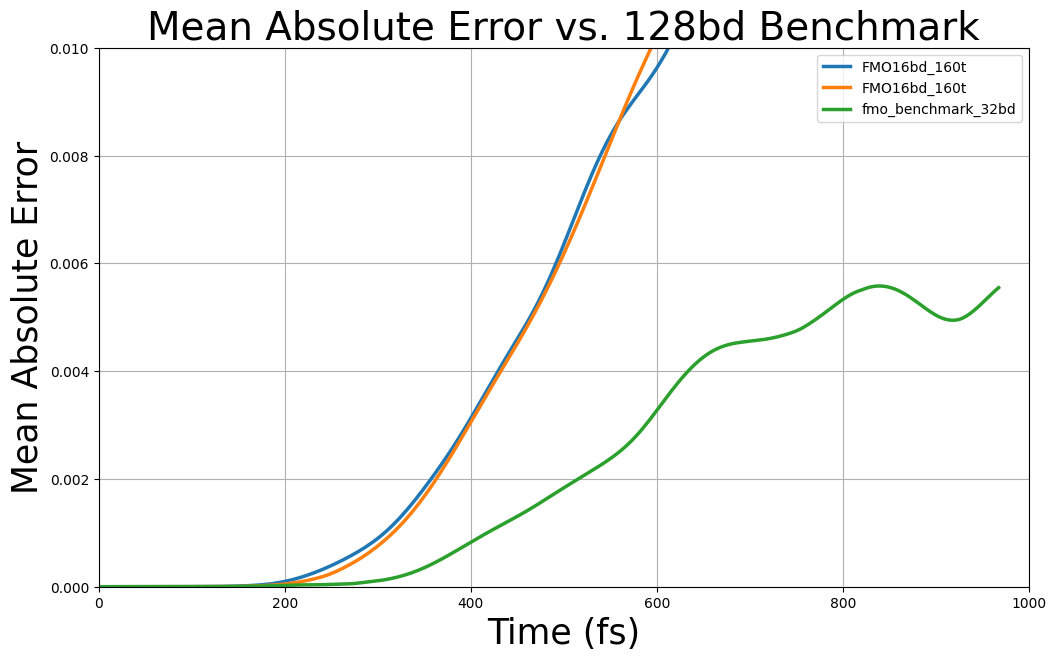

In [15]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_fmo_error():
    """
    Find all FMO simulation result files, compare them against
    the 128bd benchmark, and plot the mean absolute error over time.
    """

    # --- 1. Define paths ---
    test_dir = "../../population_2026_2"

    benchmark_file = os.path.join(test_dir, 'fmo_benchmark_128bd.xlsx')
    extra_benchmark = os.path.join(test_dir, 'fmo_benchmark_32bd.xlsx')

    # Prediction files (normal FMO runs)
    fmo_files = sorted(
        glob.glob(os.path.join(test_dir, '2*FMO*bd_*t.xlsx'))
    )

    # Add 32bd benchmark as an additional curve if it exists
    data_files = fmo_files.copy()
    if os.path.exists(extra_benchmark):
        data_files.append(extra_benchmark)

    if not data_files:
        print("Warning: No data files found to plot.")
        return

    print(f"Found {len(data_files)} data files to plot.")
    print(f"Benchmark file: {os.path.basename(benchmark_file)}")

    # --- 2. Load benchmark (128bd) ---
    df_bm = pd.read_excel(benchmark_file)

    # --- 3. Prepare benchmark time axis ---
    dt = 160 * 0.024188843265
    x_bm = np.arange(df_bm.shape[0]) * dt
    y_bm = df_bm.iloc[:, 0:7].to_numpy()

    # --- 4. Create plot ---
    fig, ax = plt.subplots(figsize=(12, 7))

    # --- 5. Loop over all data files ---
    for f in data_files:
        df_pred = pd.read_excel(f)

        x_pred = np.arange(df_pred.shape[0]) * dt
        y_pred = df_pred.iloc[:, 0:7].to_numpy()

        # Interpolate benchmark onto prediction grid
        y_bm_on_pred = np.column_stack([
            np.interp(x_pred, x_bm, y_bm[:, i]) for i in range(7)
        ])

        err = y_pred - y_bm_on_pred
        mean_abs_err = np.mean(np.abs(err), axis=1)

        # Label
        basename = os.path.basename(f)
        if basename.startswith("fmo_benchmark"):
            label = basename.replace(".xlsx", "")
        else:
            match = re.search(r'(FMO.*bd_.*t)', basename)
            label = match.group(1) if match else basename

        ax.plot(x_pred, mean_abs_err, label=label, linewidth=2.5)
        print(f"  - Plotted: {label}")

    # --- 6. Final formatting ---
    ax.set_xlabel('Time (fs)', size=25)
    ax.set_ylabel('Mean Absolute Error', size=25)
    ax.set_xlim((0, 1000))
    ax.set_ylim(bottom=0,top=0.01)
    ax.set_title('Mean Absolute Error vs. 128bd Benchmark', size=28)
    ax.legend()
    ax.grid(True)

    plt.show()


plot_fmo_error()

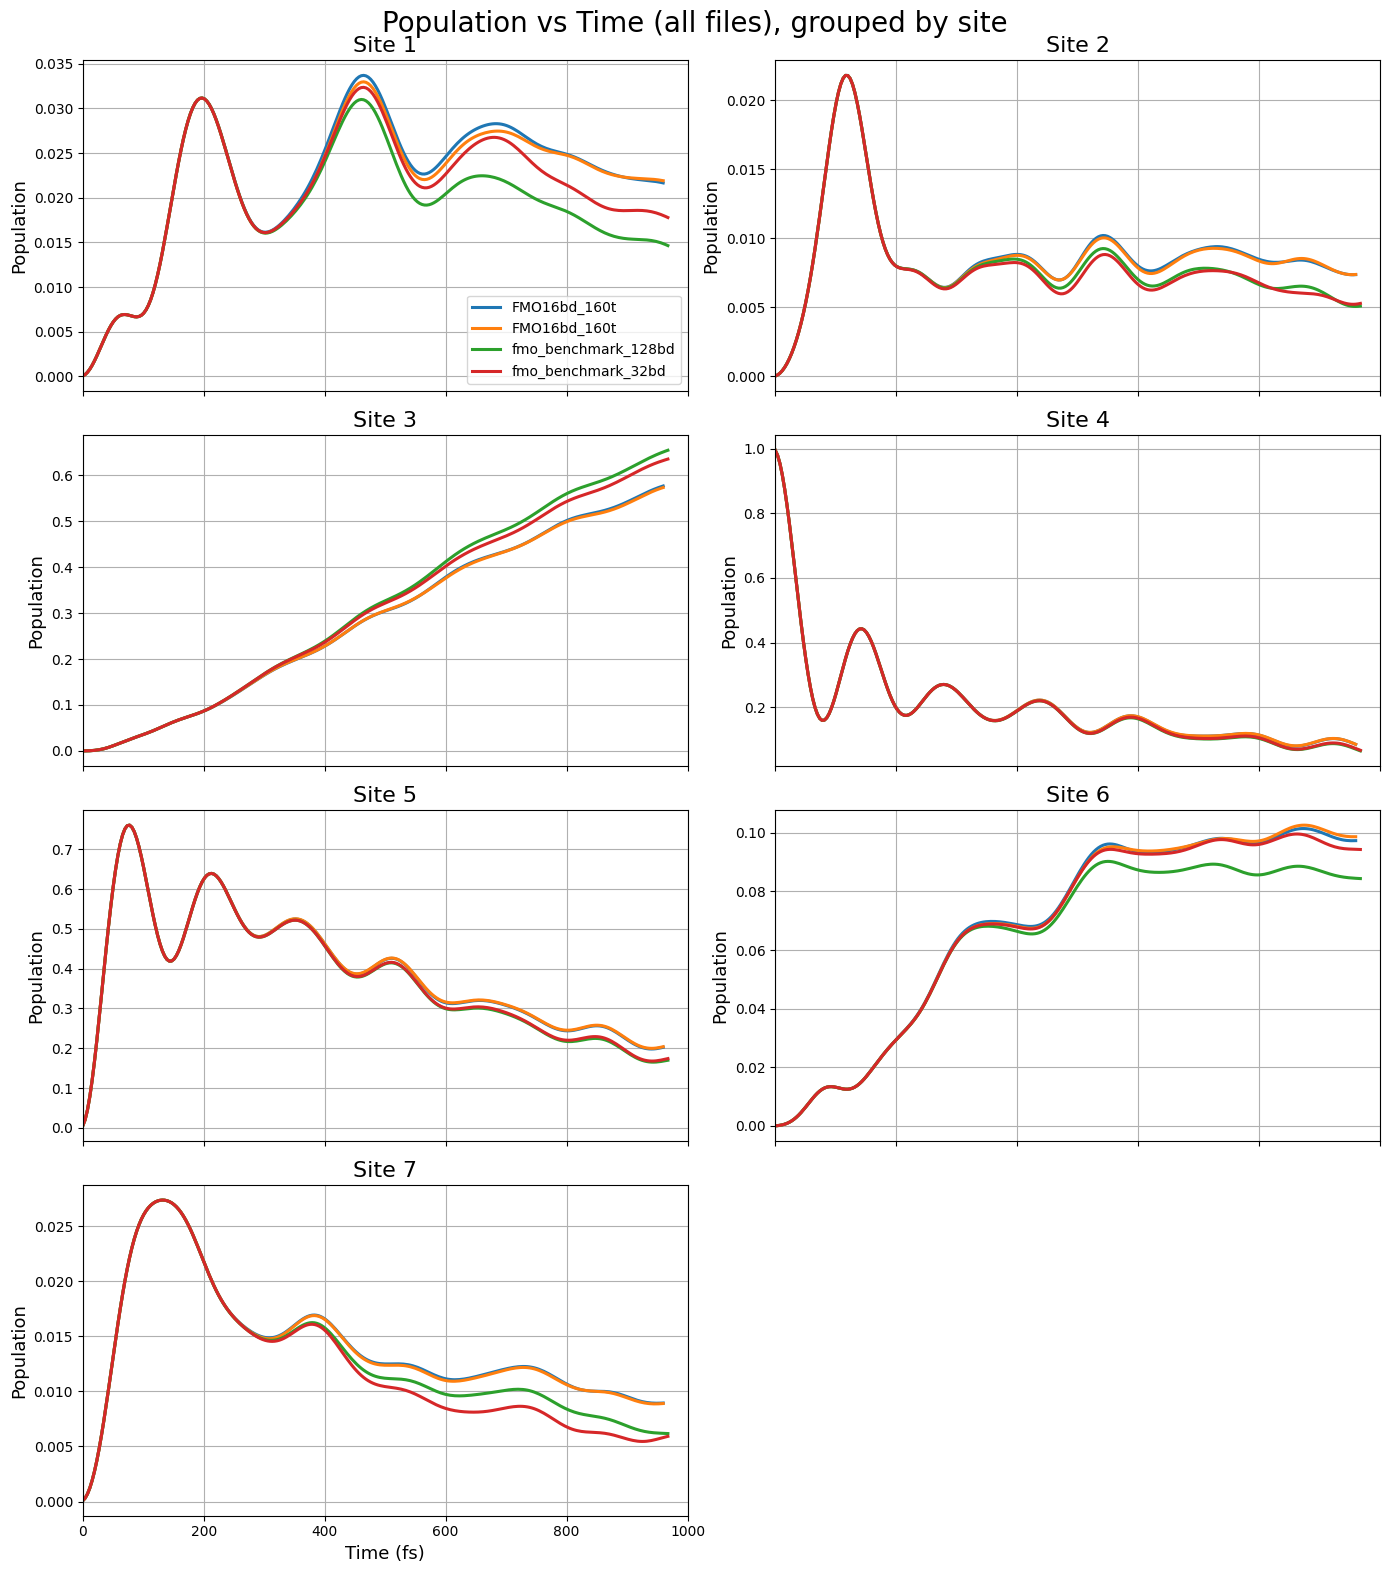

In [20]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_fmo_population_all_files_by_site(
    test_dir="",
    dt=160 * 0.024188843265,
    xlim=(0, 1000),
    include_benchmarks=True,
):
    # --- 1) Collect files ---
    fmo_files = sorted(glob.glob(os.path.join(test_dir, "*FMO*bd_*t.xlsx")))

    benchmark_128 = os.path.join(test_dir, "fmo_benchmark_128bd.xlsx")
    benchmark_32  = os.path.join(test_dir, "fmo_benchmark_32bd.xlsx")

    data_files = fmo_files.copy()
    if include_benchmarks:
        if os.path.exists(benchmark_128):
            data_files.append(benchmark_128)
        if os.path.exists(benchmark_32):
            data_files.append(benchmark_32)

    if not data_files:
        print("Warning: no data files found.")
        return

    # --- 2) Read all files once (avoid reading 7 times) ---
    series = []  # list of (label, x, y7)
    for f in data_files:
        df = pd.read_excel(f)
        y = df.iloc[:, 0:7].to_numpy()
        x = np.arange(df.shape[0]) * dt

        basename = os.path.basename(f)
        if basename.startswith("fmo_benchmark"):
            label = basename.replace(".xlsx", "")
        else:
            m = re.search(r"(FMO.*bd_.*t)", basename)
            label = m.group(1) if m else basename.replace(".xlsx", "")

        series.append((label, x, y))

    # --- 3) Create 7 subplots (one per site) ---
    fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
    axes = axes.ravel()

    for site in range(7):
        ax = axes[site]
        for label, x, y in series:
            ax.plot(x, y[:, site], linewidth=2.2, label=label)

        ax.set_title(f"Site {site+1}", fontsize=16)
        ax.set_ylabel("Population", fontsize=13)
        ax.set_xlim(xlim)
        ax.grid(True)

        # 只在第一张子图放 legend（否则会很挤）
        if site == 0:
            ax.legend(fontsize=10, ncol=1)

    # Hide the unused 8th subplot
    axes[7].axis("off")

    # common x label on bottom row
    for ax in axes[6:8]:
        if ax is not None:
            ax.set_xlabel("Time (fs)", fontsize=13)

    fig.suptitle("Population vs Time (all files), grouped by site", fontsize=20)
    fig.tight_layout()
    plt.show()


plot_fmo_population_all_files_by_site(
    test_dir="",
    xlim=(0, 1000),          # 你如果想跟前两张图一致就用 (0, 500)
    include_benchmarks=True # 是否把 benchmark 也叠加进去
)

In [4]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator   # 新增

# ========= 你需要改的参数 =========
test_dir = "../../population_2026_2"
dt = 160 * 0.024188843265  # fs
xlim = (900, 950)

ylim_all = None
ylim_by_site = {
    0: (0.014, 0.018),
    1: (0.005, 0.0065),
    2: (0.60, 0.65),
    3: (0.076, 0.090),
    4: (0.16, 0.19),
    5: (0.082, 0.102),
    6: (0.000, 0.01),
}

xlabel_size = 26
ylabel_size = 26
title_size  = 24
tick_size   = 20
legend_size = 14
labelpad_xy = 12
tick_pad    = 10
# =================================

file_list = [
    "multiset_32bd.xlsx",
    "multiset_64bd.xlsx",
    "singleset_32bd.xlsx",
    "singleset_64bd.xlsx",
    "singleset_256bd.xlsx",
]
benchmark_name = "singleset_256bd.xlsx"

linestyle_by_kind = {"multiset": "-", "singleset": "--"}

color_by_bd_kind = {
    (32,  "singleset"): "#d85c5c",
    (32,  "multiset"):  "#611E1E",
    (64,  "singleset"): "#B1C44E",
    (64,  "multiset"):  "#287246",
    (256, "singleset"): "k",
}

def parse_kind_bd(fname: str):
    if fname.startswith("singleset_"):
        kind = "singleset"
    elif fname.startswith("multiset_"):
        kind = "multiset"
    else:
        kind = "other"
    m = re.search(r"_(\d+)bd", fname)
    bd = int(m.group(1)) if m else None
    return kind, bd

def make_label(kind: str, bd: int, is_benchmark: bool):
    lab = f"{kind}, M={bd}"
    if is_benchmark:
        lab += ""
    return lab

# ---- 读取所有文件（一次性读入）----
series = []
for fname in file_list:
    fpath = os.path.join(test_dir, fname)
    if not os.path.exists(fpath):
        print(f"[Skip] Not found: {fname}")
        continue

    kind, bd = parse_kind_bd(fname)
    df = pd.read_excel(fpath)
    y = df.iloc[:, 0:7].to_numpy()
    x = np.arange(df.shape[0]) * dt

    is_benchmark = (fname == benchmark_name)

    series.append({
        "x": x,
        "y": y,
        "kind": kind,
        "bd": bd,
        "is_benchmark": is_benchmark,
        "label": make_label(kind, bd, is_benchmark),
    })

if not series:
    raise RuntimeError("No files were loaded. Please check test_dir and file names.")

kind_order = {"multiset": 0, "singleset": 1, "other": 2}
series = sorted(series, key=lambda s: (s["bd"] if s["bd"] is not None else 9999,
                                      kind_order.get(s["kind"], 9),
                                      1 if s["is_benchmark"] else 0))

# ---- 画 7 张图：每张图一个 site ----
for site in range(7):
    fig, ax = plt.subplots(figsize=(9, 6))

    for item in series:
        bd, kind = item["bd"], item["kind"]
        ls = linestyle_by_kind.get(kind, "-")
        color = color_by_bd_kind.get((bd, kind), None)

        lw = 3.6 if item["is_benchmark"] else 2.8
        z  = 10 if item["is_benchmark"] else 3

        ax.plot(item["x"], item["y"][:, site],
                linewidth=lw, linestyle=ls, color=color,
                label=item["label"], zorder=z)

    ax.set_xlabel("Time (fs)", fontsize=xlabel_size, labelpad=labelpad_xy)
    ax.set_ylabel("Population", fontsize=ylabel_size, labelpad=labelpad_xy)
    ax.set_title(f"Site {site+1}", fontsize=title_size)

    if xlim is not None:
        ax.set_xlim(xlim)

    if site in ylim_by_site and ylim_by_site[site] is not None:
        ax.set_ylim(ylim_by_site[site])
    elif ylim_all is not None:
        ax.set_ylim(ylim_all)

    # 关键新增：x/y 轴只要 5 个主刻度
    ax.xaxis.set_major_locator(MaxNLocator(5))
    ax.yaxis.set_major_locator(MaxNLocator(5))

    ax.tick_params(axis="both", which="major", labelsize=tick_size, pad=tick_pad)
    ax.grid(True)
    ax.legend(fontsize=legend_size, frameon=True)

    fig.tight_layout()
    plt.show()

[Skip] Not found: multiset_32bd.xlsx
[Skip] Not found: multiset_64bd.xlsx
[Skip] Not found: singleset_32bd.xlsx
[Skip] Not found: singleset_64bd.xlsx
[Skip] Not found: singleset_256bd.xlsx


RuntimeError: No files were loaded. Please check test_dir and file names.

In [5]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator   # 新增

# ========= 你需要改的参数 =========
test_dir = "../../population_2026_2"
dt = 160 * 0.024188843265  # fs
xlim = (900, 950)

ylim_all = None
ylim_by_site = {
    0: (0.014, 0.018),
    1: (0.005, 0.0065),
    2: (0.60, 0.65),
    3: (0.076, 0.090),
    4: (0.16, 0.19),
    5: (0.082, 0.102),
    6: (0.000, 0.01),
}

xlabel_size = 26
ylabel_size = 26
title_size  = 24
tick_size   = 20
legend_size = 14
labelpad_xy = 12
tick_pad    = 10
# =================================

file_list = [
    "multiset_64bd.xlsx",
    "multiset_128bd.xlsx",
    "singleset_64bd.xlsx",
    "singleset_128bd.xlsx",
    "singleset_256bd.xlsx",
]
benchmark_name = "singleset_256bd.xlsx"

linestyle_by_kind = {"multiset": "-", "singleset": "--"}

color_by_bd_kind = {
    (64,  "singleset"): "#d85c5c",
    (64,  "multiset"):  "#611E1E",
    (128,  "singleset"): "#B1C44E",
    (128,  "multiset"):  "#287246",
    (256, "singleset"): "k",
}

def parse_kind_bd(fname: str):
    if fname.startswith("singleset_"):
        kind = "singleset"
    elif fname.startswith("multiset_"):
        kind = "multiset"
    else:
        kind = "other"
    m = re.search(r"_(\d+)bd", fname)
    bd = int(m.group(1)) if m else None
    return kind, bd

def make_label(kind: str, bd: int, is_benchmark: bool):
    lab = f"{kind}, M={bd}"
    if is_benchmark:
        lab += ""
    return lab

# ---- 读取所有文件（一次性读入）----
series = []
for fname in file_list:
    fpath = os.path.join(test_dir, fname)
    if not os.path.exists(fpath):
        print(f"[Skip] Not found: {fname}")
        continue

    kind, bd = parse_kind_bd(fname)
    df = pd.read_excel(fpath)
    y = df.iloc[:, 0:7].to_numpy()
    x = np.arange(df.shape[0]) * dt

    is_benchmark = (fname == benchmark_name)

    series.append({
        "x": x,
        "y": y,
        "kind": kind,
        "bd": bd,
        "is_benchmark": is_benchmark,
        "label": make_label(kind, bd, is_benchmark),
    })

if not series:
    raise RuntimeError("No files were loaded. Please check test_dir and file names.")

kind_order = {"multiset": 0, "singleset": 1, "other": 2}
series = sorted(series, key=lambda s: (s["bd"] if s["bd"] is not None else 9999,
                                      kind_order.get(s["kind"], 9),
                                      1 if s["is_benchmark"] else 0))

# ---- 画 7 张图：每张图一个 site ----
for site in range(7):
    fig, ax = plt.subplots(figsize=(10, 6))

    for item in series:
        bd, kind = item["bd"], item["kind"]
        ls = linestyle_by_kind.get(kind, "-")
        color = color_by_bd_kind.get((bd, kind), None)

        lw = 3.6 if item["is_benchmark"] else 2.8
        z  = 10 if item["is_benchmark"] else 3

        ax.plot(item["x"], item["y"][:, site],
                linewidth=lw, linestyle=ls, color=color,
                label=item["label"], zorder=z)

    ax.set_xlabel("Time (fs)", fontsize=xlabel_size, labelpad=labelpad_xy)
    ax.set_ylabel("Population", fontsize=ylabel_size, labelpad=labelpad_xy)
    ax.set_title(f"Site {site+1}", fontsize=title_size)

    if xlim is not None:
        ax.set_xlim(xlim)

    if site in ylim_by_site and ylim_by_site[site] is not None:
        ax.set_ylim(ylim_by_site[site])
    elif ylim_all is not None:
        ax.set_ylim(ylim_all)

    # 关键新增：x/y 轴只要 5 个主刻度
    ax.xaxis.set_major_locator(MaxNLocator(5))
    ax.yaxis.set_major_locator(MaxNLocator(5))

    ax.tick_params(axis="both", which="major", labelsize=tick_size, pad=tick_pad)
    ax.grid(True)
    ax.legend(fontsize=legend_size, frameon=True)

    fig.tight_layout()
    plt.show()

[Skip] Not found: multiset_64bd.xlsx
[Skip] Not found: multiset_128bd.xlsx
[Skip] Not found: singleset_64bd.xlsx
[Skip] Not found: singleset_128bd.xlsx
[Skip] Not found: singleset_256bd.xlsx


RuntimeError: No files were loaded. Please check test_dir and file names.

In [6]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator   # 新增

# ========= 你需要改的参数 =========
test_dir = "../../population_2026_2"
dt = 160 * 0.024188843265  # fs
xlim = (900, 950)

ylim_all = None
ylim_by_site = {
    0: (0.014, 0.018),
    1: (0.005, 0.0065),
    2: (0.60, 0.65),
    3: (0.076, 0.090),
    4: (0.16, 0.19),
    5: (0.082, 0.102),
    6: (0.000, 0.01),
}

xlabel_size = 26
ylabel_size = 26
title_size  = 24
tick_size   = 20
legend_size = 14
labelpad_xy = 12
tick_pad    = 10
# =================================

file_list = [
    "multiset_32bd.xlsx",
    "multiset_64bd.xlsx",
    "multiset_128bd.xlsx",
    "singleset_32bd.xlsx",
    "singleset_64bd.xlsx",
    "singleset_128bd.xlsx",
    "singleset_256bd.xlsx",
]
benchmark_name = "singleset_256bd.xlsx"

linestyle_by_kind = {"multiset": "-", "singleset": "--"}

color_by_bd_kind = {
    (32,  "singleset"): "#76A2B9",
    (32,  "multiset"):  "#143673",
    (64,  "singleset"): "#d85c5c",
    (64,  "multiset"):  "#611E1E",
    (128,  "singleset"): "#B1C44E",
    (128,  "multiset"):  "#287246",
    (256, "singleset"): "k",
}

def parse_kind_bd(fname: str):
    if fname.startswith("singleset_"):
        kind = "singleset"
    elif fname.startswith("multiset_"):
        kind = "multiset"
    else:
        kind = "other"
    m = re.search(r"_(\d+)bd", fname)
    bd = int(m.group(1)) if m else None
    return kind, bd

def make_label(kind: str, bd: int, is_benchmark: bool):
    lab = f"{kind}, M={bd}"
    if is_benchmark:
        lab += ""
    return lab

# ---- 读取所有文件（一次性读入）----
series = []
for fname in file_list:
    fpath = os.path.join(test_dir, fname)
    if not os.path.exists(fpath):
        print(f"[Skip] Not found: {fname}")
        continue

    kind, bd = parse_kind_bd(fname)
    df = pd.read_excel(fpath)
    y = df.iloc[:, 0:7].to_numpy()
    x = np.arange(df.shape[0]) * dt

    is_benchmark = (fname == benchmark_name)

    series.append({
        "x": x,
        "y": y,
        "kind": kind,
        "bd": bd,
        "is_benchmark": is_benchmark,
        "label": make_label(kind, bd, is_benchmark),
    })

if not series:
    raise RuntimeError("No files were loaded. Please check test_dir and file names.")

kind_order = {"multiset": 0, "singleset": 1, "other": 2}
series = sorted(series, key=lambda s: (s["bd"] if s["bd"] is not None else 9999,
                                      kind_order.get(s["kind"], 9),
                                      1 if s["is_benchmark"] else 0))

# ---- 画 7 张图：每张图一个 site ----
for site in range(7):
    fig, ax = plt.subplots(figsize=(10, 6))

    for item in series:
        bd, kind = item["bd"], item["kind"]
        ls = linestyle_by_kind.get(kind, "-")
        color = color_by_bd_kind.get((bd, kind), None)

        lw = 3.6 if item["is_benchmark"] else 2.8
        z  = 10 if item["is_benchmark"] else 3

        ax.plot(item["x"], item["y"][:, site],
                linewidth=lw, linestyle=ls, color=color,
                label=item["label"], zorder=z)

    ax.set_xlabel("Time (fs)", fontsize=xlabel_size, labelpad=labelpad_xy)
    ax.set_ylabel("Population", fontsize=ylabel_size, labelpad=labelpad_xy)
    ax.set_title(f"Site {site+1}", fontsize=title_size)

    if xlim is not None:
        ax.set_xlim(xlim)

    if site in ylim_by_site and ylim_by_site[site] is not None:
        ax.set_ylim(ylim_by_site[site])
    elif ylim_all is not None:
        ax.set_ylim(ylim_all)

    # 关键新增：x/y 轴只要 5 个主刻度
    ax.xaxis.set_major_locator(MaxNLocator(5))
    ax.yaxis.set_major_locator(MaxNLocator(5))

    ax.tick_params(axis="both", which="major", labelsize=tick_size, pad=tick_pad)
    ax.grid(True)
    ax.legend(fontsize=legend_size, frameon=True)

    fig.tight_layout()
    plt.show()

[Skip] Not found: multiset_32bd.xlsx
[Skip] Not found: multiset_64bd.xlsx
[Skip] Not found: multiset_128bd.xlsx
[Skip] Not found: singleset_32bd.xlsx
[Skip] Not found: singleset_64bd.xlsx
[Skip] Not found: singleset_128bd.xlsx
[Skip] Not found: singleset_256bd.xlsx


RuntimeError: No files were loaded. Please check test_dir and file names.

In [22]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ========= 参数 =========
test_dir = "../../population_2026_2"
dt = 160 * 0.024188843265  # fs
xlim = (0, 950)          # None 表示全画

# True: 累计平均误差  cummean(MAE); False: 瞬时 MAE(t)
cumulative = True

xlabel_size = 26
ylabel_size = 26
title_size  = 24
tick_size   = 20
legend_size = 14
labelpad_xy = 12
tick_pad    = 10
# =======================

file_list = [
    "multiset_32bd.xlsx",
    "multiset_64bd.xlsx",
    # "multiset_128bd.xlsx",
    "singleset_32bd.xlsx",
    "singleset_64bd.xlsx",
    # "singleset_128bd.xlsx",
    "singleset_256bd.xlsx",   # benchmark
]
benchmark_name = "singleset_256bd.xlsx"

linestyle_by_kind = {"multiset": "-", "singleset": "--"}

color_by_bd_kind = {
    (32,  "singleset"): "#76A2B9",
    (32,  "multiset"):  "#143673",
    (64,  "singleset"): "#d85c5c",
    (64,  "multiset"):  "#611E1E",
    (128, "singleset"): "#B1C44E",
    (128, "multiset"):  "#287246",
    (256, "singleset"): "k",   # benchmark
}

def parse_kind_bd(fname: str):
    if fname.startswith("singleset_"):
        kind = "singleset"
    elif fname.startswith("multiset_"):
        kind = "multiset"
    else:
        kind = "other"
    m = re.search(r"_(\d+)bd", fname)
    bd = int(m.group(1)) if m else None
    return kind, bd

def make_label(kind: str, bd: int, is_benchmark: bool):
    # 按你之前格式
    return f"{kind}, M={bd}"

# ---- 读 benchmark ----
bm_path = os.path.join(test_dir, benchmark_name)
df_bm = pd.read_excel(bm_path)
y_bm = df_bm.iloc[:, 0:7].to_numpy()
x_bm = np.arange(df_bm.shape[0]) * dt

# ---- 读取其它文件并计算误差曲线 ----
series_err = []
for fname in file_list:
    if fname == benchmark_name:
        continue

    fpath = os.path.join(test_dir, fname)
    if not os.path.exists(fpath):
        print(f"[Skip] Not found: {fname}")
        continue

    kind, bd = parse_kind_bd(fname)

    df = pd.read_excel(fpath)
    y = df.iloc[:, 0:7].to_numpy()
    x = np.arange(df.shape[0]) * dt

    # 插值到 benchmark 的时间点上
    y_on_bm = np.column_stack([np.interp(x_bm, x, y[:, i]) for i in range(7)])

    # 7个site的平均绝对误差 MAE(t)
    mae = np.mean(np.abs(y_on_bm - y_bm), axis=1)

    if cumulative:
        mae_plot = np.cumsum(mae) / np.arange(1, len(mae) + 1)
    else:
        mae_plot = mae

    series_err.append({
        "x": x_bm,
        "err": mae_plot,
        "kind": kind,
        "bd": bd,
        "label": make_label(kind, bd, False),
        "color": color_by_bd_kind.get((bd, kind), None),
        "ls": linestyle_by_kind.get(kind, "-"),
    })

# 排序：bd从小到大；同bd multiset在前 singleset在后
kind_order = {"multiset": 0, "singleset": 1, "other": 2}
series_err = sorted(series_err, key=lambda s: (s["bd"], kind_order.get(s["kind"], 9)))

# ---- 作图：不同 bond dim（含 singleset/multiset）平均误差曲线 ----
fig, ax = plt.subplots(figsize=(10, 6))

for item in series_err:
    lw = 3.0
    ax.plot(item["x"], item["err"],
            color=item["color"], linestyle=item["ls"], linewidth=lw,
            label=item["label"])

# 可选：画一条0基线
ax.axhline(0, color="k", linewidth=1)

ax.set_xlabel("Time (fs)", fontsize=xlabel_size, labelpad=labelpad_xy)
ax.set_ylabel("Cumulative Mean Abs Error" if cumulative else "Mean Abs Error",
              fontsize=ylabel_size, labelpad=labelpad_xy)
ax.set_title("Mean error over 7 sites (vs singleset_256bd)", fontsize=title_size)

if xlim is not None:
    ax.set_xlim(xlim)

# 只要5个刻度
ax.xaxis.set_major_locator(MaxNLocator(5))
ax.yaxis.set_major_locator(MaxNLocator(5))

ax.tick_params(axis="both", which="major", labelsize=tick_size, pad=tick_pad)
ax.grid(True)
ax.legend(fontsize=legend_size, frameon=True)

fig.tight_layout()
plt.show()

TypeError: '<' not supported between instances of 'int' and 'NoneType'

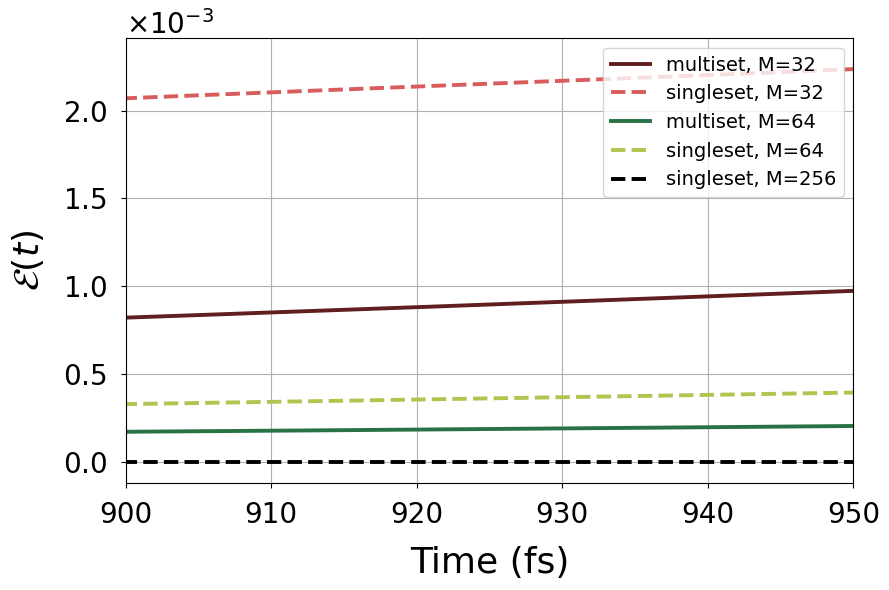

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, ScalarFormatter

# ========= 参数 =========
test_dir = "../../population_2026_2"
dt = 160 * 0.024188843265  # fs
# xlim = (0, 1000)           # 建议：如果想看全貌，可以将这里改为 None 或更大的范围
xlim = (900, 950)        # 你之前的局部放大范围

xlabel_size = 26
ylabel_size = 26
tick_size   = 20
legend_size = 14
labelpad_xy = 12
tick_pad    = 10

file_list = [
    "multiset_32bd.xlsx",
    "multiset_64bd.xlsx",
    # "multiset_128bd.xlsx",
    "singleset_32bd.xlsx",
    "singleset_64bd.xlsx",
    # "singleset_128bd.xlsx",
    "singleset_256bd.xlsx",   # benchmark
]
benchmark_name = "singleset_256bd.xlsx"

linestyle_by_kind = {"multiset": "-", "singleset": "--"}
color_by_bd_kind = {
    (32,  "singleset"): "#d85c5c",
    (32,  "multiset"):  "#611E1E",
    (64,  "singleset"): "#B1C44E",
    (64,  "multiset"):  "#287246",
    (128, "singleset"): "#76A2B9",
    (128, "multiset"):  "#143673",
    (256, "singleset"): "k",     # 黑色
}

def parse_kind_bd(fname: str):
    if fname.startswith("singleset_"):
        kind = "singleset"
    elif fname.startswith("multiset_"):
        kind = "multiset"
    else:
        kind = "other"
    m = re.search(r"_(\d+)bd", fname)
    bd = int(m.group(1)) if m else None
    return kind, bd

def make_label(kind: str, bd: int, is_benchmark: bool):
    return f"{kind}, M={bd}"

def cumulative_trapz(y, x):
    """返回与 x 同长度的累计积分（梯形法），第一个点为 0。"""
    dx = np.diff(x)
    area = 0.5 * (y[1:] + y[:-1]) * dx
    out = np.empty_like(y, dtype=float)
    out[0] = 0.0
    out[1:] = np.cumsum(area)
    return out

# ---- 读取所有文件 ----
series = []
for fname in file_list:
    fpath = os.path.join(test_dir, fname)
    if not os.path.exists(fpath):
        print(f"[Skip] Not found: {fname}")
        continue

    kind, bd = parse_kind_bd(fname)
    df = pd.read_excel(fpath)
    y = df.iloc[:, 0:7].to_numpy()
    x = np.arange(df.shape[0]) * dt

    is_benchmark = (fname == benchmark_name)
    series.append({
        "fname": fname,
        "x": x,
        "y": y,
        "kind": kind,
        "bd": bd,
        "is_benchmark": is_benchmark,
        "label": make_label(kind, bd, is_benchmark),
    })

if not series:
    raise RuntimeError("No files were loaded.")

# ---- 找 benchmark ----
bm = next((s for s in series if s["is_benchmark"]), None)
if bm is None:
    raise RuntimeError(f"Benchmark file not loaded: {benchmark_name}")

x_ref = bm["x"]
y_ref = bm["y"]

# ---- 计算并画 平均累计误差 E(t) ----
fig, ax = plt.subplots(figsize=(9, 6))

# 排序：按 bd 从小到大；同 bd 下 multiset 在前 singleset 在后
kind_order = {"multiset": 0, "singleset": 1, "other": 2}

# 【修改1】这里不再排除 benchmark，而是直接对所有 series 排序并绘图
plot_series = sorted(series, key=lambda s: (s["bd"], kind_order.get(s["kind"], 9)))

for item in plot_series:
    x = item["x"]
    y = item["y"]

    # 插值对齐
    y_ref_on_x = np.column_stack([
        np.interp(x, x_ref, y_ref[:, i]) for i in range(7)
    ])

    # 计算误差
    abs_diff = np.abs(y - y_ref_on_x)          # (T,7)
    site_sum = abs_diff.sum(axis=1)            # Σ_n |...|
    cum_int = cumulative_trapz(site_sum, x)    # ∫ Σ |...| dt

    # E(t) = cum_int / (7 t)
    E = np.full_like(x, np.nan, dtype=float)
    mask = x > 0
    E[mask] = cum_int[mask] / (7.0 * x[mask])
    E[0] = 0.0

    ls = linestyle_by_kind.get(item["kind"], "-")
    color = color_by_bd_kind.get((item["bd"], item["kind"]), None)

    # 绘制
    ax.plot(x, E, linewidth=2.8, linestyle=ls, color=color, label=item["label"])

ax.set_xlabel("Time (fs)", fontsize=xlabel_size, labelpad=labelpad_xy)
ax.set_ylabel(r"$\mathcal{E}(t)$", fontsize=ylabel_size, labelpad=labelpad_xy)

# 【修改2】去掉标题
# ax.set_title(...) 

if xlim is not None:
    ax.set_xlim(xlim)

ax.xaxis.set_major_locator(MaxNLocator(5))

# 【修改3】纵坐标使用科学计数法
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # 强制使用科学计数法 (x10^n)
ax.yaxis.set_major_formatter(formatter)
ax.yaxis.offsetText.set_fontsize(tick_size) # 设置左上角 10^n 的字体大小

ax.tick_params(axis="both", which="major", labelsize=tick_size, pad=tick_pad)

ax.grid(True)
ax.legend(fontsize=legend_size, loc='upper right',frameon=True)

fig.tight_layout()
plt.show()

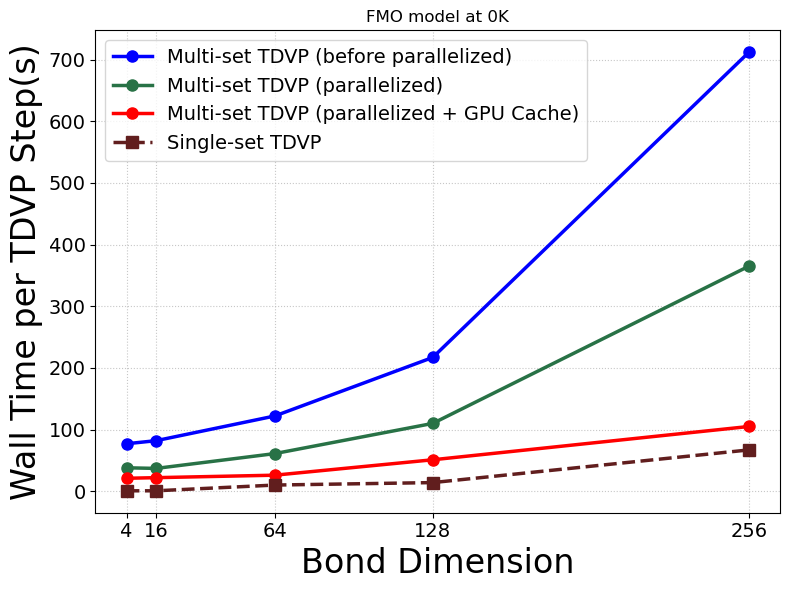

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# ========= 数据准备 =========
# 注意：为了画图连贯，通常将 x 轴从小到大排序
bond_dims = [4, 16, 64, 128, 256]

# Multiset 数据 (对应 bond_dims)
t_multiset_cache = [21, 22, 26, 51, 105]
t_multiset_para = [38, 37, 61, 110, 365]
t_multiset_nopara = [77, 82,  122, 217, 712]



# Singleset 数据 (注意：4和16没有数据，设为 None 或分开定义)
# 对应: 4(None), 16(None), 32(7), 64(10), 128(14), 256(67)
bond_dims_single = [4, 16,  64, 128, 256]
t_singleset      = [0.69, 0.69,  10, 14,  67]

# ========= 绘图 =========
fig, ax = plt.subplots(figsize=(8, 6))

# 1. 画 Multiset (实线)
ax.plot(bond_dims, t_multiset_nopara, 
        marker='o', markersize=8, 
        linestyle='-', linewidth=2.5, color = "blue",
        label='Multi-set TDVP (before parallelized)')

ax.plot(bond_dims, t_multiset_para, 
        marker='o', markersize=8, 
        linestyle='-', linewidth=2.5, color = "#287246",
        label='Multi-set TDVP (parallelized)')

ax.plot(bond_dims, t_multiset_cache, 
        marker='o', markersize=8, 
        linestyle='-', linewidth=2.5, color = "#FF0000",
        label='Multi-set TDVP (parallelized + GPU Cache)')

# 2. 画 Singleset (虚线)
ax.plot(bond_dims_single, t_singleset, 
        marker='s', markersize=8, 
        linestyle='--', linewidth=2.5, color = "#611E1E",
        label='Single-set TDVP')




# ========= 装饰 =========
ax.set_xlabel("Bond Dimension", fontsize=24)
ax.set_ylabel("Wall Time per TDVP Step(s)", fontsize=24)
ax.set_title("FMO model at 0K")
# 设置横坐标刻度，只显示数据点对应的数值
ax.set_xticks(bond_dims)
ax.set_xticklabels(bond_dims)

# 如果觉得横坐标 4-32 挤在一起，可以取消下面这行的注释开启对数坐标
# ax.set_xscale("log", base=2)

ax.tick_params(axis='both', which='major', labelsize=14)
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(fontsize=14)

plt.tight_layout()
plt.show()